In [25]:
import pandas as pd
import collections
import plotnine as p9
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import calcutta
import scipy.sparse as sp
from importlib import reload
reload(calcutta)

<module 'calcutta' from '/gpfs/commons/home/daknowles/calcutta/calcutta.py'>

In [3]:
cell_ec = np.load("corrected.compressed.npz") 
cell_ec = cell_ec["arr_0"]

In [13]:
umi_counts = cell_ec[2,:]
indices = cell_ec[:2,:]
cell_ec_sparse = sp.coo_matrix((umi_counts, indices))

In [15]:
pseudobulk = np.squeeze(np.asarray(cell_ec_sparse.sum(0)))

In [315]:
with open("corrected.ec","r") as f: 
    ecs = [ [int(g) for g in s.strip().split(",")] for s in f.readlines()[1:] ]
len(ecs)

418040

In [366]:
datadir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/kallisto_output/merged/")
indexdir = Path("/gpfs/commons/groups/knowles_lab/index/kallisto/mus_musculus/")

count_file = datadir / "correct100.txt.gz"

transcripts, t2g_dic = calcutta.get_transcript_gene_map(
    datadir / "transcripts.txt",
    indexdir / "transcripts_to_genes.txt")

In [26]:
ec_transcript_mat = calcutta.ecs_to_sparse(ecs)

In [27]:
x = pseudobulk[1:]

In [52]:
ec_transcript_mat.shape

(418040, 118489)

In [45]:
ec_sizes = sparse_sum(ec_transcript_mat,1)

Text(0, 0.5, 'log10(UMI count)')

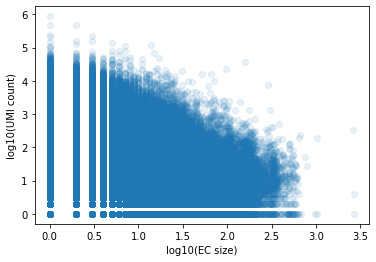

In [50]:
plt.scatter(np.log10(ec_sizes), np.log10(x), alpha=0.1)
plt.xlabel("log10(EC size)")
plt.ylabel("log10(UMI count)")

In [99]:
from scipy.sparse.csgraph import connected_components
g = ec_transcript_mat.T @ ec_transcript_mat
n_components, labels = connected_components(csgraph=g, directed=False, return_labels=True)
n_components # 19163!

19189

In [62]:
pd.Series(labels).value_counts().max()

67493

In [116]:
res = []
for threshold in (10, 20, 30, 50, 100, 1e5): 
    print(threshold)
    big_ECs = ec_sizes >= threshold
    prop_UMIs_lost = sum(x[big_ECs]) / sum(x)
    ec_trans_sub = sp.csr_matrix(ec_transcript_mat)[~big_ECs,:]
    g = ec_trans_sub.T @ ec_trans_sub
    n_components, labels = connected_components(csgraph=g, directed=False, return_labels=True)
    res.append( (
        threshold, 
        sum(ec_sizes >= threshold), 
        n_components, 
        pd.Series(labels).value_counts().max(), 
        prop_UMIs_lost,
        len(g.data) / np.prod(g.shape)) )

10
20
30
50
100
100000.0


In [317]:
res

[(10, 87469, 21431, 64652, 0.06389463726518288, 8.028480427070252e-05),
 (20, 42321, 19896, 66758, 0.022533073398792652, 0.00011754771725867433),
 (30, 27116, 19758, 67050, 0.011005147485042438, 0.0001412291596667573),
 (50, 14075, 19599, 67222, 0.004960848654367365, 0.0001777046594772913),
 (100, 4768, 19486, 67274, 0.0014992389417782834, 0.00024394914959605118),
 (100000.0, 0, 19189, 67493, 0.0, 0.001087994963144904)]

So unfortunately removing large ECs doesn't change the size of the largest component much. It does make it more sparse however. 

In [97]:
ec_transcript_mat.shape

(418040, 118489)

0.001087994963144904

In [96]:
pd.Series(labels).value_counts()

146      67493
2694       216
2139        71
6479        57
654         56
         ...  
8708         1
8709         1
8712         1
8713         1
19188        1
Length: 19189, dtype: int64

In [104]:
big_comp = sp.csr_matrix(g)[labels==146,labels==146]
label = 146
l = np.where(labels==label)[0]
subg = g[np.ix_(l,l)]

In [108]:
len(subg.data) / np.prod(subg.shape) # 0.03% nonzero, still very sparse! conjugate gradient could be good? 

0.003282425400529966

In [103]:
g.shape

(118489, 118489)

In [31]:
indexdir = Path("/gpfs/commons/groups/knowles_lab/index/kallisto/mus_musculus/")
transcript_lengths_dic = calcutta.get_transcript_lengths(indexdir / "Mus_musculus.GRCm38.cdna.all.fa")

In [34]:
(np.asarray(ec_transcript_mat.sum(0))==0).sum()

7196

In [35]:
fragment_size = 300
eff_lens = np.array([ 
    ((g-fragment_size) if (g>fragment_size) else g) 
    for g in transcript_lengths_dic.values() ]) # discontinous :(
w = 1. / eff_lens

In [36]:
n_transcripts = len(eff_lens)
alpha = np.full(n_transcripts,1.0/n_transcripts)

In [37]:
alpha_w = ec_transcript_mat.copy()


In [38]:
def sparse_sum(x, dim):
    return np.squeeze(np.asarray(x.sum(dim)))

In [118]:
for i in range(30):
    alpha_w.data = (alpha * w)[ec_transcript_mat.col]
    ec_sums = sparse_sum(alpha_w,1)
    z = sp.diags(x / ec_sums) @ alpha_w
    alpha_new = sparse_sum(z,0)
    alpha_new /= alpha_new.sum()
    print(i,np.mean(np.abs(alpha - alpha_new)),end="\r")
    alpha = alpha_new

In [40]:
sparse_sum(ec_transcript_mat)

TypeError: sparse_sum() missing 1 required positional argument: 'dim'

In [120]:
# Try to calculate Hessian
alpha_w.data = (alpha * w)[ec_transcript_mat.col]
ec_sums = sparse_sum(alpha_w,1)
diag_w = sp.diags(w)
neg_hessian = sp.diags(w) @ ec_transcript_mat.T @ sp.diags(x / (ec_sums * ec_sums)) @ ec_transcript_mat @ sp.diags(w)

In [162]:
ec_sums

array([1.87182962e-10, 1.22009584e-09, 1.60442539e-10, ...,
       2.74566990e-05, 2.77969839e-05, 2.81305222e-05])

In [ ]:
# TODO: check we are getting sparsity from x. Use hessian.eliminate_zeros()? 

In [329]:
# x will help make this more sparse than otherwise

(418040, 118489)

In [125]:
from scipy.sparse.csgraph import connected_components
n_components, labels = connected_components(csgraph=neg_hessian, directed=False, return_labels=True)
n_components # 19163!

19189

In [126]:
pd.Series(labels).value_counts()

146      67493
2694       216
2139        71
6479        57
654         56
         ...  
8708         1
8709         1
8712         1
8713         1
19188        1
Length: 19189, dtype: int64

In [171]:
#for label in range(n_components):
label=146
wh = labels==label
nhessian_csc = sp.csc_matrix(neg_hessian)
#if sum(wh)==1: continue # just reciprocal
l = np.where(labels==label)[0]
subhess = nhessian_csc[np.ix_(l,l)]
#subhess
#a = np.linalg.inv(subhess.todense())

In [181]:
"%.4g" % subhess.data.mean()

'2.899e+12'

In [183]:
from sksparse.cholmod import cholesky
subhess.data /= subhess.data.mean()
ch = cholesky(subhess + 1e-11 * sp.eye(subhess.shape[0]))

In [186]:
"%.4g" % nhessian_csc.data.mean()
nhessian_csc.data /= nhessian_csc.data.mean()

'9.542e+12'

In [436]:
start_time = time.time()
ch = cholesky(nhessian_csc, beta=1e-11)
time.time() - start_time # 10 seconds(!)

9.595332622528076

In [434]:
import time

A = sp.csc_matrix(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]))
A = A @ A.T
b = np.array([1, 2, 3])

ch = cholesky(A, beta=0.3)

x = ch.solve_L(b, use_LDLt_decomposition = False)
x.dot(x)
# 0.04s per solve. 

1.0620198728147123

In [435]:
x = ch(b)
b.dot(x)

0.08349813227861999

In [200]:
start_time = time.time()
#inv_hess = sp.linalg.factorized(nhessian_csc + 1e-11 * sp.eye(nhessian_csc.shape[0])) # much slower!
time.time() - start_time # 10minutes

592.0229859352112

In [319]:
suppa_se = pd.read_csv("/gpfs/commons/home/daknowles/calcutta/suppa_mouse/suppaout_SE_strict.ioe", sep="\t")

In [369]:
transcripts_no_v = [ g.split('.')[0] for g in transcripts ]
tnv2idx = {t:i for i,t in enumerate(transcripts_no_v) }

In [382]:
alt_trans = [ [ tnv2idx.get(trans,-1) for trans in g.split(",") ] for g in suppa_se.alternative_transcripts ]

In [383]:
tot_trans = [ [ tnv2idx.get(trans,-1) for trans in g.split(",") ] for g in suppa_se.total_transcripts ]
has_missing = [ (-1 in g) for g in tot_trans]
np.mean( has_missing ) # 7%, guess just drop these? TODO: figure out where these come from

0.06732012063765619

In [384]:
to_keep = np.where(np.logical_not(has_missing))[0]
tot_trans = [ tot_trans[g] for g in to_keep ]
alt_trans = [ alt_trans[g] for g in to_keep ]

In [449]:
ref_trans = [ list(set(tot) - set(alt)) for alt,tot in zip(alt_trans,tot_trans) ]

In [455]:
def to_coo(alt_trans, num_transcripts):
    nnz = sum([len(g) for g in alt_trans])

    indices = np.zeros((2,nnz), dtype=int) # cell then EC idx

    nz_idx = 0
    for idx,trans_list in enumerate(alt_trans): 
        nhere = len(trans_list)
        indices[0,nz_idx:nz_idx+nhere] = idx
        indices[1,nz_idx:nz_idx+nhere] = trans_list
        nz_idx += nhere
    
    return sp.coo_matrix((np.ones(nnz), indices), shape = (len(alt_trans), num_transcripts))
alt_trans_mat = to_coo(alt_trans, len(transcripts)) # event x transcripts
ref_trans_mat = to_coo(ref_trans, len(transcripts))

In [456]:
len(transcripts)

118489

In [390]:
event_idx = 0
tot_trans[event_idx]

[82612, 82613, 82611, 82610, 82609, 82607, 82608]

In [460]:
alt_tpm = alt_trans_mat @ alpha
ref_tpm = ref_trans_mat @ alpha

In [461]:
logit_psi = np.log(alt_tpm) - np.log(ref_tpm) # add pseudocount?
logit_psi

<ipython-input-461-d5e5c0d1b8dc>:1: RuntimeWarning: divide by zero encountered in log
<ipython-input-461-d5e5c0d1b8dc>:1: RuntimeWarning: invalid value encountered in subtract


array([ 5.41954683, 49.93194355,  3.13702948, ...,  0.0667042 ,
       -0.1728897 ,         nan])

In [467]:
grad_logit_psi = sp.diags(1. / alt_tpm) @ alt_trans_mat - sp.diags(1. / ref_tpm) @ ref_trans_mat

<ipython-input-467-67a4bdf48f7c>:1: RuntimeWarning: divide by zero encountered in true_divide


In [478]:
# I wonder if this might actually be faster if grad_logit_psi were dense? 
start_time = time.time()
Linv_grad = ch.solve_L(grad_logit_psi.T , use_LDLt_decomposition = False)
time.time() - start_time # ~6minutes for 17k events

376.92350459098816

In [484]:
Linv_grad.data *= Linv_grad.data

<ipython-input-484-98427e8229d2>:1: RuntimeWarning: overflow encountered in multiply


In [487]:
sparse_sum(Linv_grad,0) # variance for event logitPSI

array([6.94207329e+24, 2.07431897e+63, 5.98829338e+09, ...,
       3.96690224e+12, 1.62118785e+10,            nan])

In [ ]:
x = ch.solve_L(b, use_LDLt_decomposition = False)
x.dot(x)

In [471]:
grad_logit_psi.T.shape

(118489, 17318)

In [477]:
(6.5 / 300) * 17000 / 60

6.138888888888889

In [1]:
376.92350459098816 / 60

6.282058409849802